In [ ]:
# 📌 Step 1: Imports & GPU/CPU Setup
import os
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [5]:
# 📌 Check GPU availability
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ Using GPU: {len(gpus)} device(s) available.")
    except RuntimeError as e:
        print(f"⚠️ GPU configuration error: {e}")
else:
    print("⚙️ Using CPU: No GPU found.")

⚙️ Using CPU: No GPU found.


In [ ]:
# 📌 Step 2: Constants and Paths
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20
NUM_CLASSES = 4

TRAIN_DIR = "../dataset/train"
VAL_DIR = "../dataset/test"
MODEL_SAVE_PATH = "notebooks/models/CNN_leaf_disease_model.keras"  # Save model in Keras format


In [4]:
# 📌 Step 3: Data Preparation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 3209 images belonging to 4 classes.
Found 880 images belonging to 4 classes.


In [5]:
# 📌 Step 4: Custom CNN Model
model = Sequential()

# Add first convolutional layer
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Add second convolutional layer
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Add third convolutional layer
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Flatten the output from convolutional layers
model.add(Flatten())

# Add fully connected layers
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Add output layer with softmax activation (for multi-class classification)
model.add(Dense(NUM_CLASSES, activation='softmax'))

c:\Users\avtka\Desktop\grape leaf cnn\grapEnv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
# 📌 Step 5: Compile Model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# 📌 Step 6: Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
checkpoint = ModelCheckpoint(MODEL_SAVE_PATH, monitor='val_accuracy', save_best_only=True)


In [8]:
# 📌 Step 7: Train Model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint]
)


c:\Users\avtka\Desktop\grape leaf cnn\grapEnv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 98s 955ms/step - accuracy: 0.4844 - loss: 1.1164 - val_accuracy: 0.5773 - val_loss: 0.8615
Epoch 2/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 89s 879ms/step - accuracy: 0.7053 - loss: 0.6946 - val_accuracy: 0.6375 - val_loss: 0.7121
Epoch 3/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 87s 861ms/step - accuracy: 0.7533 - loss: 0.6039 - val_accuracy: 0.8159 - val_loss: 0.4884
Epoch 4/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 89s 878ms/step - accuracy: 0.7877 - loss: 0.5255 - val_accuracy: 0.8386 - val_loss: 0.4552
Epoch 5/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 89s 881ms/step - accuracy: 0.8156 - loss: 0.4944 - val_accuracy: 0.8432 - val_loss: 0.4501
Epoch 6/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 89s 877ms/step - accuracy: 0.8437 - loss: 0.4313 - val_accuracy: 0.8477 - val_loss: 0.4343
Epoch 7/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 88s 874ms/step - accuracy: 0.8399 - loss: 0.4103 - val_accuracy: 0.8239 - val_loss: 0.4449
Epoch 8/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 89s 881ms/step - accuracy: 0.8658 - loss: 0

In [9]:
# 📌 Step 8: Save the Trained Model
model.save(MODEL_SAVE_PATH)  # Saving the model after training

print(f"✅ Model saved successfully at {MODEL_SAVE_PATH}")


✅ Model saved successfully at models/CNN_leaf_disease_model.keras


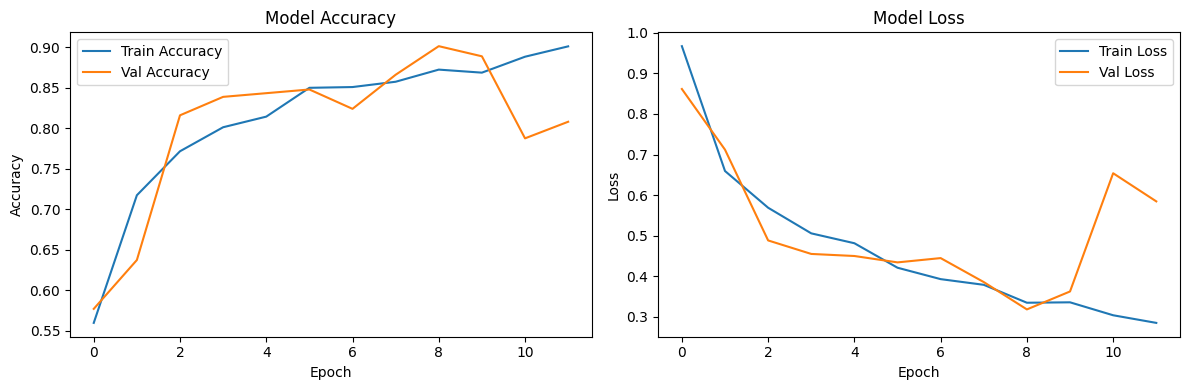

In [10]:
# 📌 Step 9: Plot Accuracy and Loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()